# Практическое занятие №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

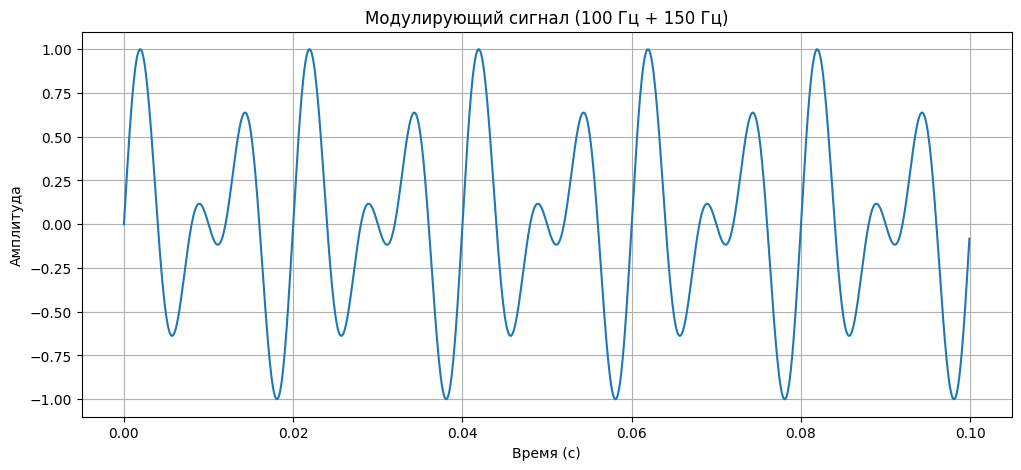

In [2]:
fm1 = 100
fm2 = 150
m_t = np.sin(2 * np.pi * fm1 * t) + np.sin(2 * np.pi * fm2 * t)
m_t = m_t / np.max(np.abs(m_t))  # нормализация к [-1, 1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 150 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()


### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [3]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)


### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [4]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)


Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

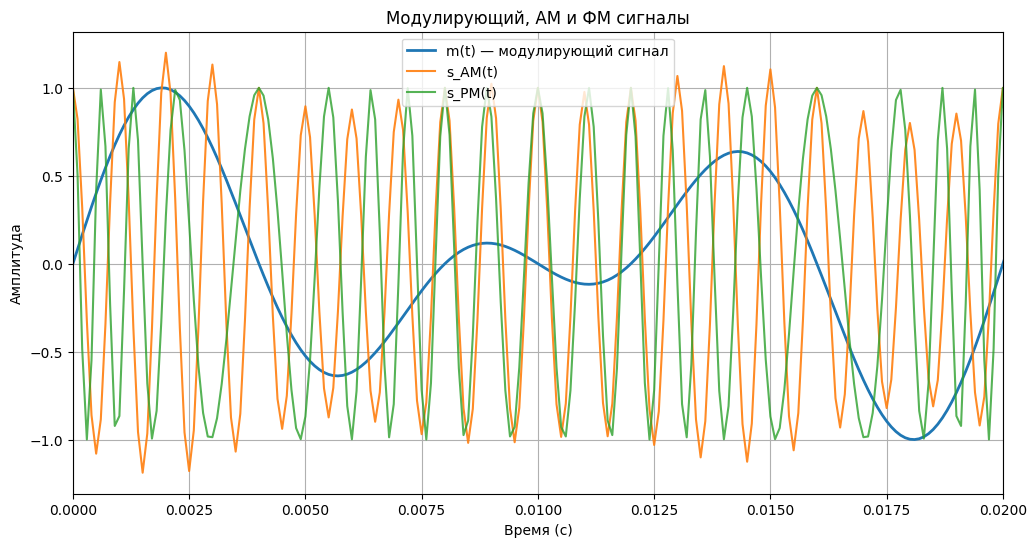

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(t, m_t, label='m(t) — модулирующий сигнал', linewidth=2)
plt.plot(t, s_am, label='s_AM(t)', alpha=0.9)
plt.plot(t, s_pm, label='s_PM(t)', alpha=0.8)
plt.xlim(0, 0.02)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Модулирующий, АМ и ФМ сигналы')
plt.legend()
plt.grid(True)
plt.show()


## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [6]:
def plot_spectrum(s, fs, title):
    s = np.asarray(s)
    n = len(s)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    spectrum = np.fft.rfft(s)
    amp = 2 * np.abs(spectrum) / n
    amp[0] = np.abs(spectrum[0]) / n

    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amp)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### 2.2. Спектр АМ

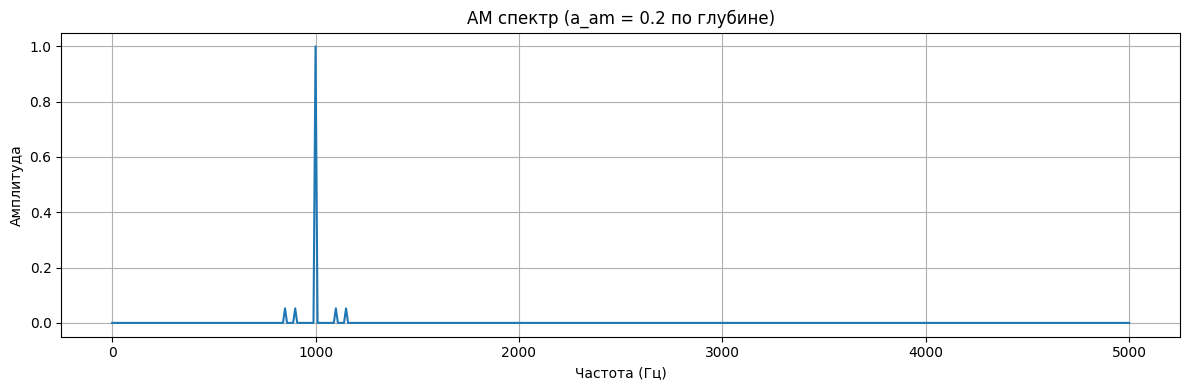

In [7]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')


### 2.3. Спектр ФМ при разных индексах модуляции

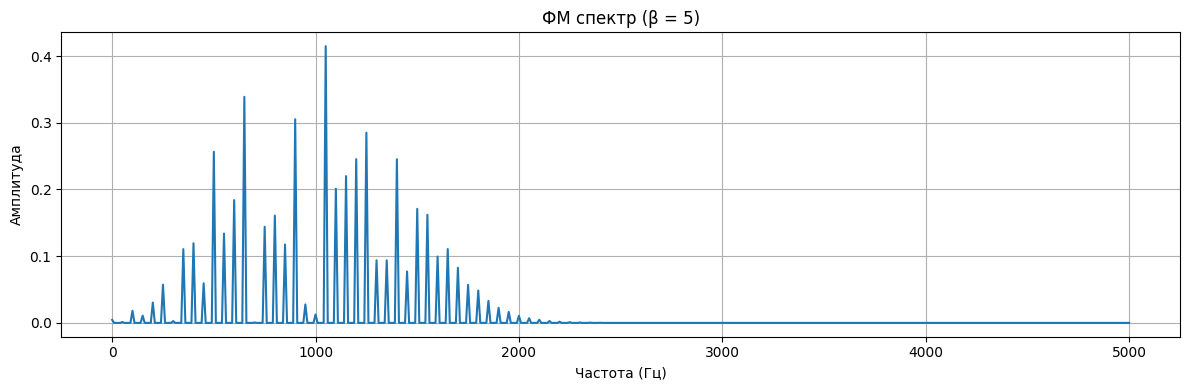

In [8]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

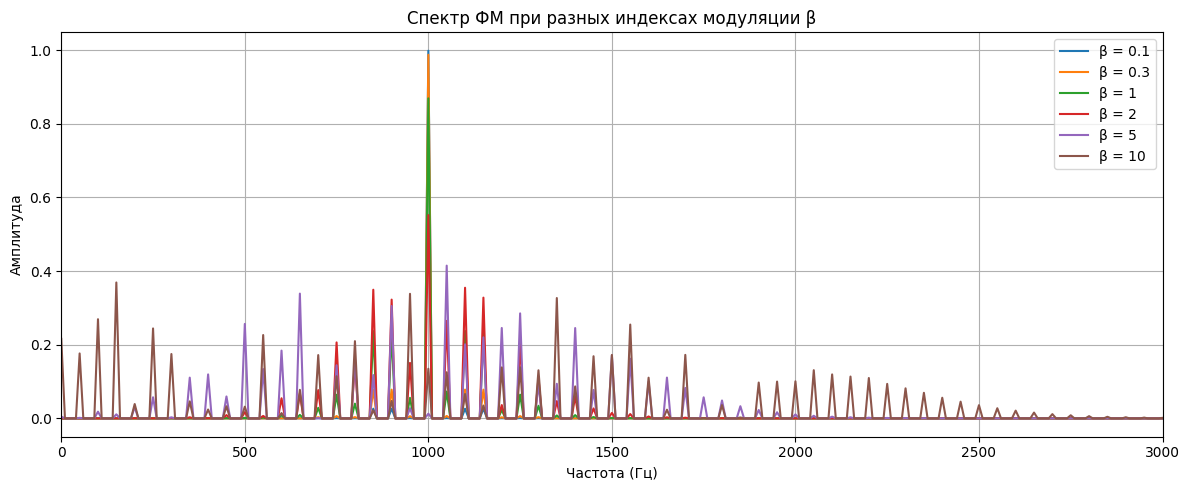

In [9]:
betas = [0.1, 0.3, 1, 2, 5, 10]

plt.figure(figsize=(12, 5))
for b in betas:
    s_pm_b = Ac * np.cos(2 * np.pi * fc * t + b * m_t)
    n = len(s_pm_b)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    spectrum = np.fft.rfft(s_pm_b)
    amp = 2 * np.abs(spectrum) / n
    amp[0] = np.abs(spectrum[0]) / n
    plt.plot(freqs, amp, label=f'β = {b}')

plt.xlim(0, 3000)
plt.title('Спектр ФМ при разных индексах модуляции β')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [10]:
def pm_spectrum(beta=5):
    s_pm_beta = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
    n = len(s_pm_beta)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    spectrum = np.fft.rfft(s_pm_beta)
    amp = 2 * np.abs(spectrum) / n
    amp[0] = np.abs(spectrum[0]) / n

    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amp)
    plt.xlim(0, 3000)
    plt.title(f'ФМ спектр (β = {beta:.1f})')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));


interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

- У АМ-сигнала модуляция линейная: произведение несущей на сумму двух синусоид даёт несущую $f_c$ и боковые компоненты на частотах $f_c\pm f_{m1}$ и $f_c\pm f_{m2}$. Поэтому видим 5 основных линий (если смотреть только положительные частоты).
- При малых $\beta$ ФМ является узкополосной: спектр сосредоточен около несущей, доминируют несущая и ближайшие боковые полосы (похоже на АМ с малой глубиной модуляции).
- При увеличении $\beta$ энергия перераспределяется из несущей в большее число боковых полос: несущая уменьшается (по функциям Бесселя, вплоть до почти нуля для некоторых $\beta$), а спектр расширяется.


## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

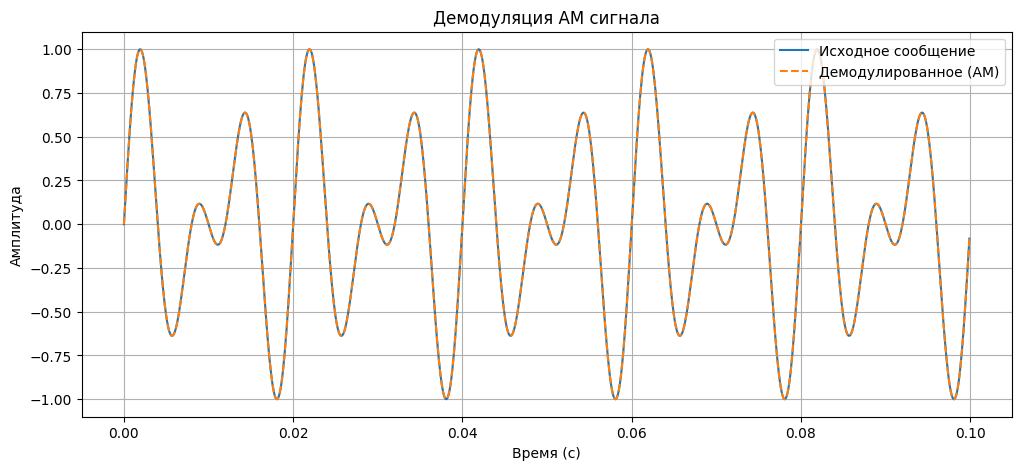

In [11]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

::Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [12]:
rmse_am = np.std(m_t - demod_am)
print(f'СКО между исходным и демодулированным АМ сообщением: {rmse_am:.6f}')


СКО между исходным и демодулированным АМ сообщением: 0.000000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

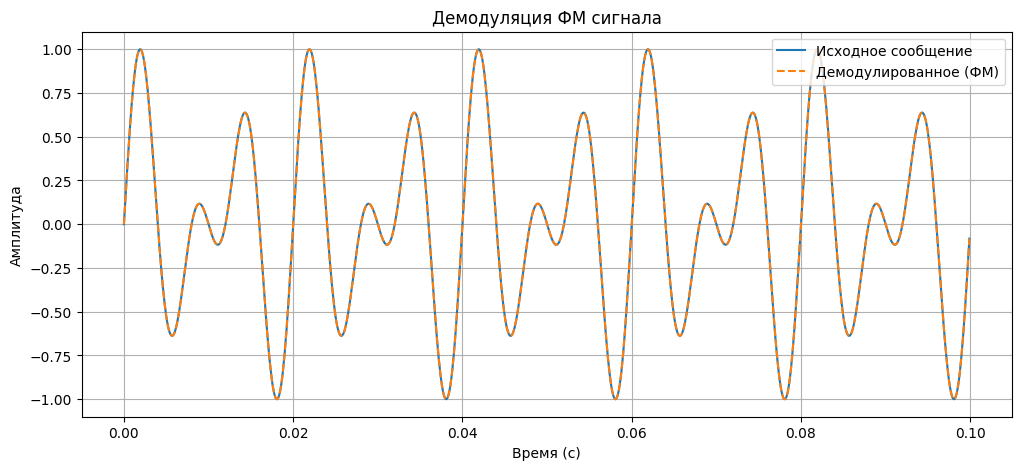

In [13]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

`np.unwrap` нужен, потому что `np.angle` возвращает фазу в диапазоне $[-\pi, \pi]$ и создаёт скачки на $2\pi$. Без развёртки эти скачки превращаются в ложные резкие изменения фазы и сильно искажают демодуляцию. `unwrap` делает фазу непрерывной и позволяет корректно вычесть линейный тренд несущей.


## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [14]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-30 18:20:22--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-30 18:20:22--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.1s    

2026-03-30 18:20:23 (3.98 MB/s) - ‘audio.wav’ saved [563756/563756]



In [15]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

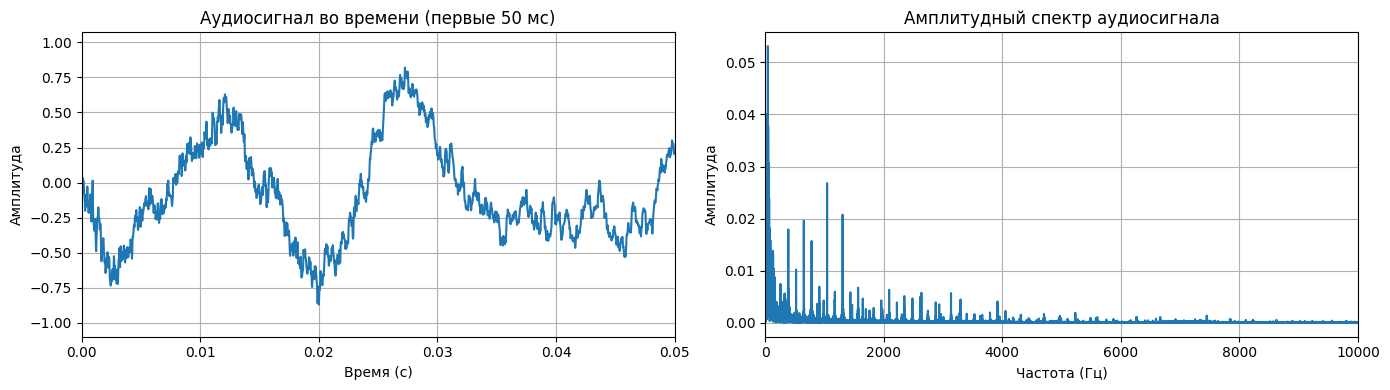

In [16]:
n_audio = len(melody)
freqs_audio = np.fft.rfftfreq(n_audio, d=1 / fs_audio)
spec_audio = np.fft.rfft(melody)
amp_audio = 2 * np.abs(spec_audio) / n_audio
amp_audio[0] = np.abs(spec_audio[0]) / n_audio

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(t_audio, melody)
plt.xlim(0, 0.05)
plt.title('Аудиосигнал во времени (первые 50 мс)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freqs_audio, amp_audio)
plt.xlim(0, 10000)
plt.title('Амплитудный спектр аудиосигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()


**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

По спектру видно, что наиболее заметные пики сосредоточены в области примерно до 3-4 кГц (основная энергия сигнала лежит ещё ниже). При $f_s=44{,}1$ кГц (частота Найквиста 22{,}05 кГц) разумно выбирать несущую около 5-8 кГц, чтобы верхние боковые полосы не ушли в область наложения спектров. В этой работе выбран компромисс `f_c = 5` кГц.

При увеличении индекса ФМ ($\beta$) спектр расширяется (появляется больше боковых полос), поэтому при большом $\beta$ риск искажений/алиасинга выше. Значит, чем больше $\beta$, тем аккуратнее нужно выбирать $f_c$ (или уменьшать $\beta$).


### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [17]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [18]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [19]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [20]:
# Нормализованный эталон для сравнения
melody_ref = melody - np.mean(melody)
melody_ref = melody_ref / np.max(np.abs(melody_ref))

# Демодуляция АМ (без шума)
analytic_am_audio = hilbert(s_am_audio)
envelope_am_audio = np.abs(analytic_am_audio)
demod_am_audio = (envelope_am_audio / Ac - 1) / a_am
demod_am_audio = demod_am_audio - np.mean(demod_am_audio)
demod_am_audio = demod_am_audio / np.max(np.abs(demod_am_audio))

print('Демодулированное АМ-аудио (без шума):')
display(Audio(demod_am_audio, rate=fs_audio))


Демодулированное АМ-аудио (без шума):


Демодулируйте зашумлёный АМ-сигнал.

In [21]:
# Демодуляция зашумлённого АМ-сигнала
analytic_am_noisy = hilbert(s_am_noisy)
envelope_am_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = (envelope_am_noisy / Ac - 1) / a_am
demod_am_noisy = demod_am_noisy - np.mean(demod_am_noisy)
demod_am_noisy = demod_am_noisy / np.max(np.abs(demod_am_noisy))

err_am_clean = np.std(melody_ref - demod_am_audio)
err_am_noisy = np.std(melody_ref - demod_am_noisy)
print(f'СКО АМ (без шума): {err_am_clean:.4f}')
print(f'СКО АМ (с шумом):  {err_am_noisy:.4f}')

print('Демодулированное АМ-аудио (с шумом):')
display(Audio(demod_am_noisy, rate=fs_audio))


СКО АМ (без шума): 0.0408
СКО АМ (с шумом):  0.1943
Демодулированное АМ-аудио (с шумом):


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

- Без шума качество после АМ-демодуляции практически сохраняется (разница небольшая и в основном связана с огибающей/нормировкой).
- При фиксированном $a_{AM}=0.2$ заметная деградация обычно начинает слышаться примерно при амплитуде шума порядка $0.03\text{--}0.05$; при $\ge 0.1$ искажения уже выраженные.
- При фиксированном шуме $0.01$ малые глубины модуляции ($a_{AM}\lesssim 0.1$) дают более заметные искажения, а при $a_{AM}\approx 0.3\text{--}0.8$ восстановление устойчивее.

Вывод: при прочих равных больший $a_{AM}$ повышает устойчивость к амплитудному шуму (лучше отношение полезной огибающей к шуму), но $a_{AM}$ нельзя делать больше 1 из-за риска перемодуляции.


**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [22]:
# Демодуляция ФМ (без шума)
analytic_pm_audio = hilbert(s_pm_audio)
inst_phase_audio = np.unwrap(np.angle(analytic_pm_audio))
phase_no_carrier_audio = inst_phase_audio - 2 * np.pi * fc_high * t_audio

demod_pm_audio = phase_no_carrier_audio - np.mean(phase_no_carrier_audio)
demod_pm_audio = demod_pm_audio / beta_pm_audio
demod_pm_audio = demod_pm_audio / np.max(np.abs(demod_pm_audio))

print('Демодулированное ФМ-аудио (без шума):')
display(Audio(demod_pm_audio, rate=fs_audio))


Демодулированное ФМ-аудио (без шума):


Демодулируйте зашумлёный ФМ-сигнал.

In [23]:
# Демодуляция зашумлённого ФМ-сигнала
analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_noisy = inst_phase_noisy - 2 * np.pi * fc_high * t_audio

demod_pm_noisy = phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)
demod_pm_noisy = demod_pm_noisy / beta_pm_audio
demod_pm_noisy = demod_pm_noisy / np.max(np.abs(demod_pm_noisy))

err_pm_clean = np.std(melody_ref - demod_pm_audio)
err_pm_noisy = np.std(melody_ref - demod_pm_noisy)
print(f'СКО ФМ (без шума): {err_pm_clean:.4f}')
print(f'СКО ФМ (с шумом):  {err_pm_noisy:.4f}')

print('Демодулированное ФМ-аудио (с шумом):')
display(Audio(demod_pm_noisy, rate=fs_audio))


СКО ФМ (без шума): 0.0124
СКО ФМ (с шумом):  0.0346
Демодулированное ФМ-аудио (с шумом):


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

- Без шума ФМ после демодуляции обычно звучит очень близко к исходному сигналу.
- При фиксированном $\beta=2$ заметная деградация обычно начинается при амплитуде шума примерно от $0.1\text{--}0.15$; при $0.03\text{--}0.05$ искажения, как правило, слабее, чем для АМ.
- При фиксированном шуме $0.1$ малые $\beta$ (около $0.2\text{--}1$) дают более заметные искажения, а увеличение $\beta$ до $2\text{--}5$ повышает помехоустойчивость.

Итого: ФМ обычно устойчивее к амплитудному шуму, но рост $\beta$ расширяет спектр, поэтому есть компромисс между устойчивостью и занимаемой полосой частот.


### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

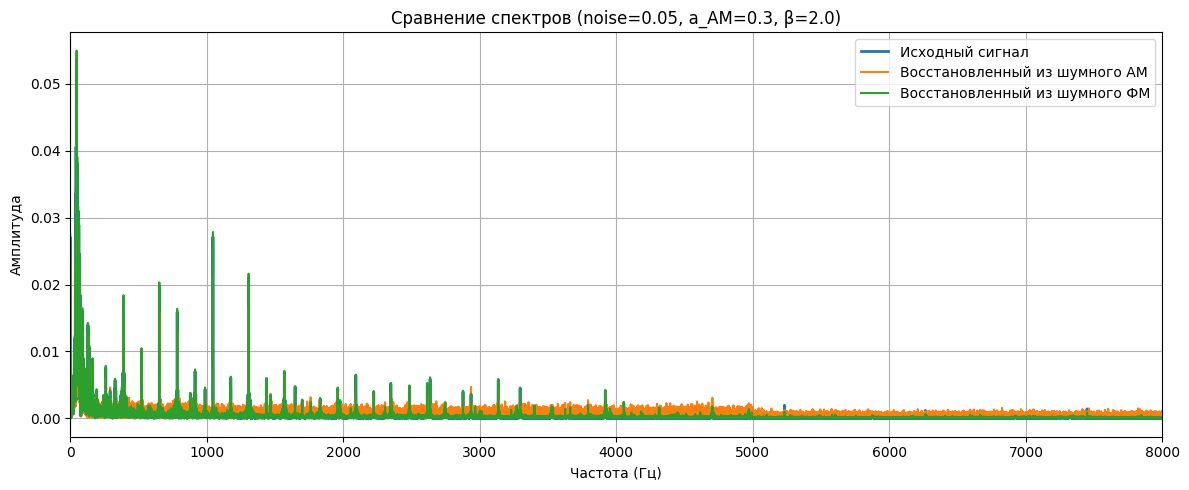

СКО (АМ): 0.1105
СКО (ФМ): 0.0189


In [24]:
# Подбираем параметры для умеренно заметных искажений
noise_level_cmp = 0.05
a_am_cmp = 0.3
beta_cmp = 2.0
np.random.seed(42)

noise_cmp = noise_level_cmp * np.random.randn(len(t_audio))

# Модуляция
s_am_cmp = Ac * (1 + a_am_cmp * melody_ref) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_cmp = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_cmp * melody_ref)

# Добавление шума
s_am_cmp_noisy = s_am_cmp * (1 + noise_cmp)
s_pm_cmp_noisy = s_pm_cmp * (1 + noise_cmp)

# Демодуляция АМ
env_cmp = np.abs(hilbert(s_am_cmp_noisy))
demod_am_cmp = (env_cmp / Ac - 1) / a_am_cmp
demod_am_cmp = demod_am_cmp - np.mean(demod_am_cmp)
demod_am_cmp = demod_am_cmp / np.max(np.abs(demod_am_cmp))

# Демодуляция ФМ
ph_cmp = np.unwrap(np.angle(hilbert(s_pm_cmp_noisy)))
demod_pm_cmp = ph_cmp - 2 * np.pi * fc_high * t_audio
demod_pm_cmp = demod_pm_cmp - np.mean(demod_pm_cmp)
demod_pm_cmp = demod_pm_cmp / beta_cmp
demod_pm_cmp = demod_pm_cmp / np.max(np.abs(demod_pm_cmp))

# Спектры восстановленных сигналов
n = len(melody_ref)
f = np.fft.rfftfreq(n, d=1 / fs_audio)

S0 = np.fft.rfft(melody_ref)
SAM = np.fft.rfft(demod_am_cmp)
SPM = np.fft.rfft(demod_pm_cmp)

A0 = 2 * np.abs(S0) / n
Aam = 2 * np.abs(SAM) / n
Apm = 2 * np.abs(SPM) / n
A0[0] = np.abs(S0[0]) / n
Aam[0] = np.abs(SAM[0]) / n
Apm[0] = np.abs(SPM[0]) / n

plt.figure(figsize=(12, 5))
plt.plot(f, A0, label='Исходный сигнал', linewidth=2)
plt.plot(f, Aam, label='Восстановленный из шумного АМ')
plt.plot(f, Apm, label='Восстановленный из шумного ФМ')
plt.xlim(0, 8000)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title(f'Сравнение спектров (noise={noise_level_cmp}, a_AM={a_am_cmp}, β={beta_cmp})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f'СКО (АМ): {np.std(melody_ref - demod_am_cmp):.4f}')
print(f'СКО (ФМ): {np.std(melody_ref - demod_pm_cmp):.4f}')


**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Да, искажения видны в обоих случаях: появляются дополнительные компоненты и растёт «шумовой фон» спектра. При одинаковых параметрах шум обычно сильнее искажает восстановление для АМ (больше поднятие фона и отклонение амплитуд пиков), тогда как для ФМ основные пики сохраняются ближе к исходным.


Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

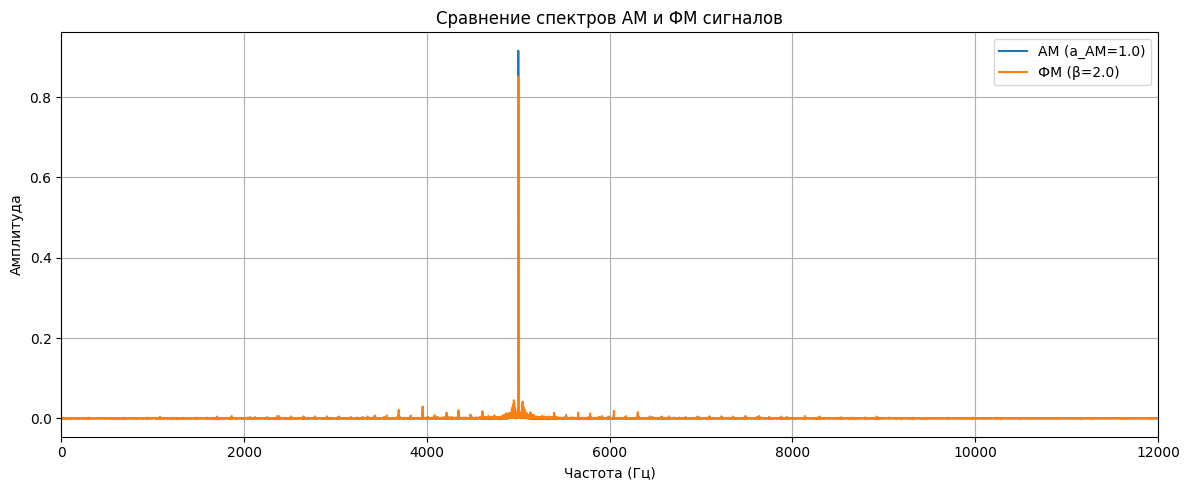

In [25]:
beta_fixed = 2.0
a_am_match = 1.0  # подобрано так, чтобы боковые компоненты АМ были сопоставимы с ФМ при beta=2

s_am_match = Ac * (1 + a_am_match * melody_ref) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_match = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_fixed * melody_ref)

n = len(melody_ref)
f = np.fft.rfftfreq(n, d=1 / fs_audio)
SAM = np.fft.rfft(s_am_match)
SPM = np.fft.rfft(s_pm_match)
Aam = 2 * np.abs(SAM) / n
Apm = 2 * np.abs(SPM) / n
Aam[0] = np.abs(SAM[0]) / n
Apm[0] = np.abs(SPM[0]) / n

plt.figure(figsize=(12, 5))
plt.plot(f, Aam, label=f'АМ (a_AM={a_am_match})')
plt.plot(f, Apm, label=f'ФМ (β={beta_fixed})')
plt.xlim(0, 12000)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Сравнение спектров АМ и ФМ сигналов')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

Для случая с $\beta=2$ и подобранным $a_{AM}=1.0$ заметные искажения обычно начинают слышаться примерно при амплитуде шума:
- для АМ: около $0.05$ (и выше);
- для ФМ: около $0.1$ (и выше).

Вывод: даже при сопоставимых по уровню боковых компонентах ФМ обычно выдерживает больший амплитудный шум до заметной деградации. Цена за это преимущество - более широкий спектр при росте индекса модуляции.
